In [91]:
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

keras = tf.keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input


In [92]:
MODEL_PATH = "../models/best_effb4.keras"
IMG_PATH = r"C:\Users\Ekaansh\OneDrive\Desktop\AB\pneu val\pneu\person1946_bacteria_4875.jpeg"

In [93]:
with open(f"{MODEL_PATH}/config.json", "r") as f:
    config = json.load(f)

model = keras.Model.from_config(config["config"])
model.load_weights(f"{MODEL_PATH}/model.weights.h5")

print("Model Loaded Successfully ✅")

Model Loaded Successfully ✅


In [94]:
img_cv = cv2.imread(IMG_PATH)

h, w, _ = img_cv.shape

# moderate crop
img_cv = img_cv[
    int(0.03*h):int(0.97*h),
    int(0.08*w):int(0.92*w)
]

img_cv = cv2.resize(img_cv, (380, 380))

img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

img_array = np.expand_dims(img_rgb, axis=0)

img_array = preprocess_input(img_array)

In [95]:
preds = model.predict(img_array)

if isinstance(preds, list):
    preds = preds[0]

pred_prob = preds[0][0]

THRESHOLD = 0.5

pred_class = 1 if pred_prob > THRESHOLD else 0

print("Prediction probability:", pred_prob)
print("Predicted class:", pred_class)

if pred_class == 0:
    print("NORMAL")
else:
    print("PNEUMONIA")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction probability: 0.9512244
Predicted class: 1
PNEUMONIA


In [96]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if isinstance(predictions, list):
            predictions = predictions[0]

        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_mean(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    # remove weak activations
    heatmap = np.where(heatmap > 0.55, heatmap, 0)

    return heatmap

In [97]:
candidate_layers = [
    "block5f_project_conv",
    "block6h_project_conv",
    "block7b_project_conv"
]

Testing layer: block5f_project_conv


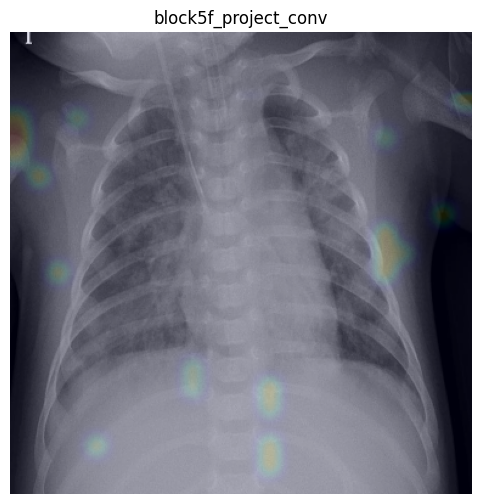

Testing layer: block6h_project_conv


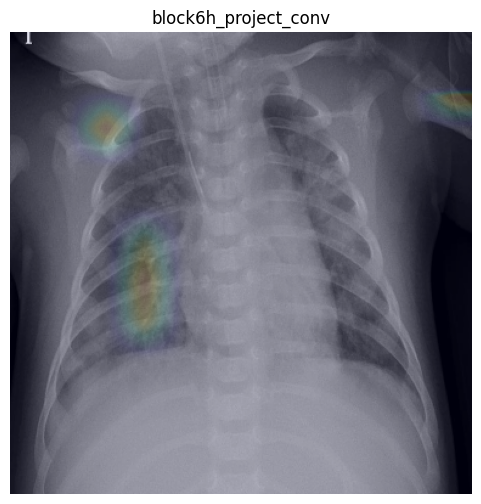

Testing layer: block7b_project_conv


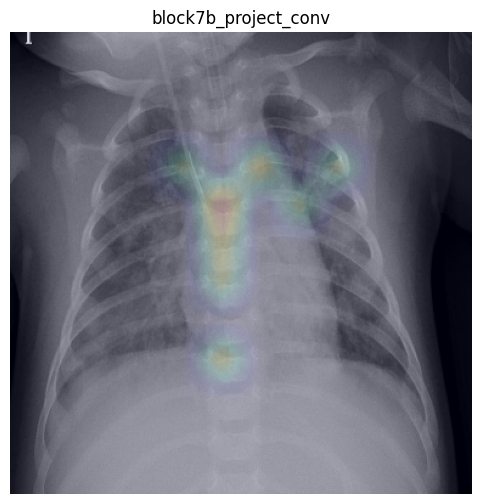

In [98]:
for layer_name in candidate_layers:

    print(f"Testing layer: {layer_name}")

    heatmap = make_gradcam_heatmap(img_array, model, layer_name)

    img_cv = cv2.imread(IMG_PATH)

    h, w, _ = img_cv.shape

    img_cv = img_cv[
        int(0.03*h):int(0.97*h),
        int(0.08*w):int(0.92*w)
    ]

    img_cv = cv2.resize(img_cv, (380, 380))

    heatmap_resized = cv2.resize(heatmap, (380, 380))
    heatmap_resized = np.uint8(255 * heatmap_resized)

    # suppress top artifact band
    heatmap_resized[:50, :] = 0

    # smooth heatmap
    heatmap_resized = cv2.GaussianBlur(heatmap_resized, (15,15), 0)

    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    # cleaner overlay
    superimposed_img = cv2.addWeighted(img_cv, 0.9, heatmap_color, 0.1, 0)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(layer_name)
    plt.show()


In [101]:
import os

SAVE_DIR = r"C:\Users\Ekaansh\OneDrive\Desktop\AB\research\SHAP\finding\eff_b4 gradcam"

os.makedirs(SAVE_DIR, exist_ok=True)

image_paths = [
    r"C:\Users\Ekaansh\OneDrive\Desktop\AB\pneu val\normal\NORMAL2-IM-1427-0001.jpeg",
    r"C:\Users\Ekaansh\OneDrive\Desktop\AB\pneu val\normal\NORMAL2-IM-1430-0001.jpeg",
    r"C:\Users\Ekaansh\OneDrive\Desktop\AB\pneu val\normal\NORMAL2-IM-1431-0001.jpeg",
    r"C:\Users\Ekaansh\OneDrive\Desktop\AB\pneu val\normal\NORMAL2-IM-1436-0001.jpeg",
    r"C:\Users\Ekaansh\OneDrive\Desktop\AB\pneu val\normal\NORMAL2-IM-1437-0001.jpeg",
    r"C:\Users\Ekaansh\OneDrive\Desktop\AB\pneu val\normal\NORMAL2-IM-1438-0001.jpeg",
    r"C:\Users\Ekaansh\OneDrive\Desktop\AB\pneu val\normal\NORMAL2-IM-1440-0001.jpeg",
    r"C:\Users\Ekaansh\OneDrive\Desktop\AB\pneu val\normal\NORMAL2-IM-1442-0001.jpeg"
]

layer_name = "block6h_project_conv"

for IMG_PATH in image_paths:

    img = image.load_img(IMG_PATH, target_size=(380, 380))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    heatmap = make_gradcam_heatmap(img_array, model, layer_name)

    img_cv = cv2.imread(IMG_PATH)
    img_cv = cv2.resize(img_cv, (380, 380))

    heatmap_resized = cv2.resize(heatmap, (380, 380))
    heatmap_resized = np.uint8(255 * heatmap_resized)

    # suppress top artifacts
    heatmap_resized[:50, :] = 0

    # blur
    heatmap_resized = cv2.GaussianBlur(heatmap_resized, (15,15), 0)

    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img_cv, 0.9, heatmap_color, 0.1, 0)

    # save filename
    filename = os.path.basename(IMG_PATH)
    save_path = os.path.join(SAVE_DIR, filename)

    cv2.imwrite(save_path, superimposed_img)

    print(f"Saved: {save_path}")

Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\research\SHAP\finding\eff_b4 gradcam\NORMAL2-IM-1427-0001.jpeg
Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\research\SHAP\finding\eff_b4 gradcam\NORMAL2-IM-1430-0001.jpeg
Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\research\SHAP\finding\eff_b4 gradcam\NORMAL2-IM-1431-0001.jpeg
Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\research\SHAP\finding\eff_b4 gradcam\NORMAL2-IM-1436-0001.jpeg
Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\research\SHAP\finding\eff_b4 gradcam\NORMAL2-IM-1437-0001.jpeg
Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\research\SHAP\finding\eff_b4 gradcam\NORMAL2-IM-1438-0001.jpeg
Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\research\SHAP\finding\eff_b4 gradcam\NORMAL2-IM-1440-0001.jpeg
Saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\research\SHAP\finding\eff_b4 gradcam\NORMAL2-IM-1442-0001.jpeg
